<a href="https://colab.research.google.com/github/ProfeAgudelo/Estadistica_inferencial_26I/blob/main/Clase_6_de_mayo_Soluci%C3%B3n_ejercicios_pruebas_de_hip%C3%B3tesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import t
from scipy.stats import chi2
from scipy.stats import norm

In [7]:
def calcular_p_valor_z(z_stat):
    """
    Calcula el valor p para una prueba Z de dos colas.

    Parámetros:
    z_stat (float): El estadístico Z calculado.
    """
    # Usamos abs() para asegurar que evaluamos la cola superior,
    # sf() calcula el área a la derecha, y multiplicamos por 2 para ambas colas.
    p_valor = 2 * norm.sf(abs(z_stat))
    return p_valor

def calcular_p_valor_t(t_stat, grados_libertad):
    """
    Calcula el valor p para una prueba t de Student de dos colas.

    Parámetros:
    t_stat (float): El estadístico t calculado.
    grados_libertad (int/float): Grados de libertad (n - 1).
    """
    p_valor = 2 * t.sf(abs(t_stat), grados_libertad)
    return p_valor

def calcular_p_valor_chi2(chi2_stat, grados_libertad, tipo_prueba='derecha'):
    """
    Calcula el valor p para una prueba de Chi-cuadrado.
    Por defecto, asume una prueba de cola derecha (la más común para varianzas).

    Parámetros:
    chi2_stat (float): El estadístico Chi-cuadrado calculado.
    grados_libertad (int/float): Grados de libertad (n - 1).
    tipo_prueba (str): 'derecha', 'izquierda' o 'dos_colas'.
    """
    if tipo_prueba == 'derecha':
        p_valor = chi2.sf(chi2_stat, grados_libertad)
    elif tipo_prueba == 'izquierda':
        p_valor = chi2.cdf(chi2_stat, grados_libertad)
    elif tipo_prueba == 'dos_colas':
        # Calcula la probabilidad de la cola más pequeña y la multiplica por 2
        p_derecha = chi2.sf(chi2_stat, grados_libertad)
        p_izquierda = chi2.cdf(chi2_stat, grados_libertad)
        p_valor = 2 * min(p_derecha, p_izquierda)
    else:
        raise ValueError("tipo_prueba debe ser 'derecha', 'izquierda' o 'dos_colas'")

    return p_valor

#Ejercicio #1


In [3]:
n = 36
x_bar = 12.19
mu_0 = 12
s = 0.11

t_calculado = (x_bar - mu_0) / (s / np.sqrt(n))
print(f'El valor t calculado es: {t_calculado:.4f}')

El valor t calculado es: 10.3636


In [17]:
alfa = 0.05
valor_p = calcular_p_valor_t(t_calculado, grados_libertad=n-1)
print(f'El valor p calculado es: {valor_p:.4f}')

if valor_p < alfa:
  print('Se rechaza H0')
else:
  print('No se rechaza H0')

El valor p calculado es: 0.0000
Se rechaza H0


In [12]:
t_critico = t.ppf(1 - (alfa/2), n-1)
print(f"Frontera crítica: ±{t_critico:.3f}")

if t_calculado < -t_critico or t_calculado > t_critico:
  print('Se rechaza H0')
else:
  print('No se rechaza H0')

Frontera crítica: ±2.030
Se rechaza H0


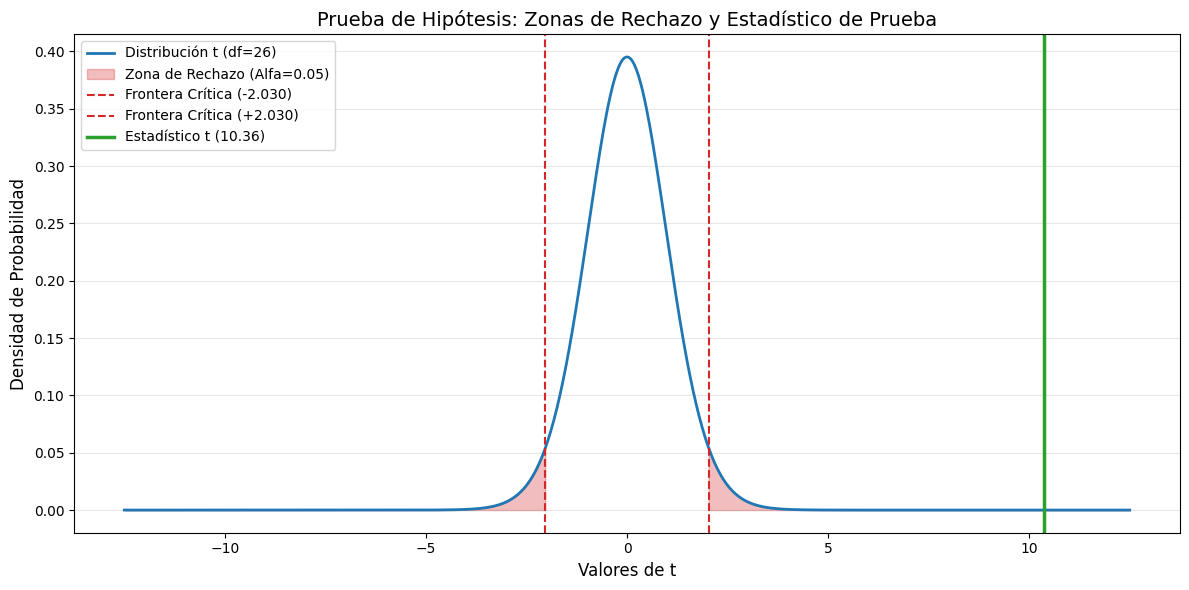

In [25]:
inicio = -12.5
fin = 12.5
x = np.linspace(inicio, fin, 1000)

# Calcular los valores de la distribución t para esos puntos X
y = t.pdf(x, n-1)

plt.figure(figsize=(12, 6))

# 1. Dibujar la campana principal
plt.plot(x, y, label=f'Distribución t (df={n-1})', color='#1f77b4', linewidth=2)

# 2. Sombrear la zona de rechazo izquierda
x_izq = np.linspace(inicio, -t_critico, 100)
plt.fill_between(x_izq, t.pdf(x_izq, n-1), color='#d62728', alpha=0.3, label='Zona de Rechazo (Alfa=0.05)')

# 3. Sombrear la zona de rechazo derecha
x_der = np.linspace(t_critico, fin, 100)
plt.fill_between(x_der, t.pdf(x_der, n-1), color='#d62728', alpha=0.3)

# 4. Marcar las banderas (Valores críticos)
plt.axvline(-t_critico, color='#d62728', linestyle='--', linewidth=1.5, label=f'Frontera Crítica (-{t_critico:.3f})')
plt.axvline(t_critico, color='#d62728', linestyle='--', linewidth=1.5, label=f'Frontera Crítica (+{t_critico:.3f})')

# 5. Marcar tu estadístico calculado (Tu ubicación)
plt.axvline(t_calculado, color='#2ca02c', linewidth=2.5, label=f'Estadístico t ({t_calculado:.2f})')

# Configuraciones de estética del gráfico
plt.title('Prueba de Hipótesis: Zonas de Rechazo y Estadístico de Prueba', fontsize=14)
plt.xlabel('Valores de t', fontsize=12)
plt.ylabel('Densidad de Probabilidad', fontsize=12)
plt.legend(loc='upper left')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#Ejercicio #2

In [15]:
n=27
s= 0.17
sigma = 0.15

chi2_calculado = ((n - 1) * s**2) / sigma**2
print(f'El valor chi2 calculado es: {chi2_calculado:.4f}')

El valor chi2 calculado es: 33.3956


In [18]:
alfa = 0.05
valor_p = calcular_p_valor_chi2(chi2_calculado, grados_libertad=n-1)
print(f'El valor p calculado es: {valor_p:.4f}')

if valor_p < alfa:
  print('Se rechaza H0')
else:
  print('No se rechaza H0')

El valor p calculado es: 0.1509
No se rechaza H0


In [20]:
alfa = 0.05
grados_libertad = n - 1

# Frontera izquierda (el 2.5% más bajo)
chi2_crit_izq = chi2.ppf(alfa/2, grados_libertad)
# Frontera derecha (el 2.5% más alto)
chi2_crit_der = chi2.ppf(1 - alfa/2, grados_libertad)

print(f"Frontera Izquierda: {chi2_crit_izq:.3f}")
print(f"Frontera Derecha: {chi2_crit_der:.3f}")

if chi2_calculado < chi2_crit_izq or chi2_calculado > chi2_crit_der:
  print('Se rechaza H0')
else:
  print('No se rechaza H0')


Frontera Izquierda: 13.844
Frontera Derecha: 41.923
No se rechaza H0


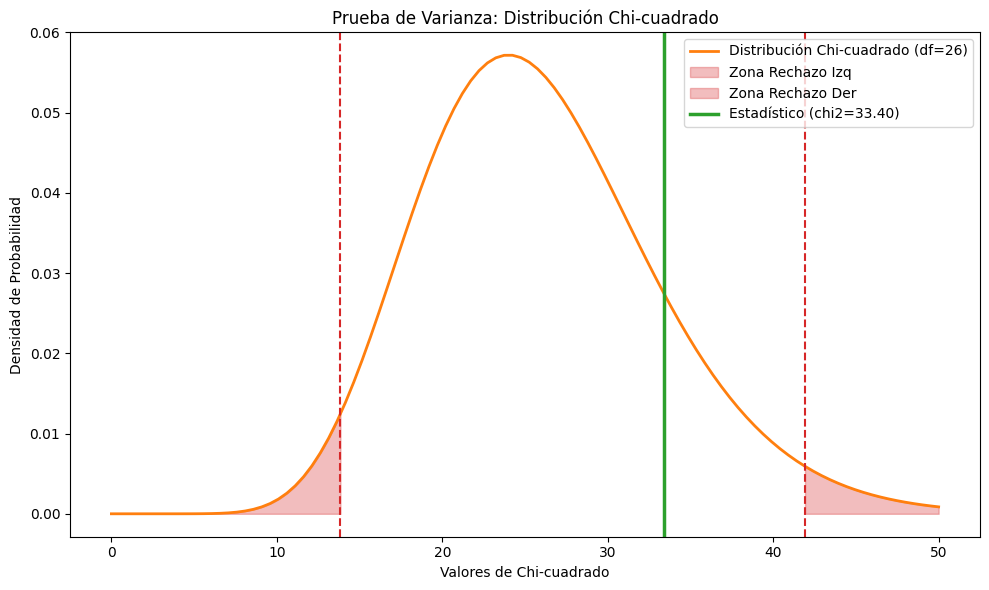

In [26]:
# Configurar valores para la gráfica
inicio = 0
fin = 50
x = np.linspace(inicio, fin, 100)
y = chi2.pdf(x, grados_libertad)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label=f'Distribución Chi-cuadrado (df={grados_libertad})', color='#ff7f0e', linewidth=2)

# Colorear zonas de rechazo
x_izq = np.linspace(inicio, chi2_crit_izq, 100)
plt.fill_between(x_izq,chi2.pdf(x_izq, grados_libertad), color='#d62728', alpha=0.3, label='Zona Rechazo Izq')

x_der = np.linspace(chi2_crit_der, fin, 100)
plt.fill_between(x_der, chi2.pdf(x_der, grados_libertad), color='#d62728', alpha=0.3, label='Zona Rechazo Der')

# Líneas de las fronteras
plt.axvline(chi2_crit_izq, color='#d62728', linestyle='--')
plt.axvline(chi2_crit_der, color='#d62728', linestyle='--')

# Marcar el valor calculado
plt.axvline(chi2_calculado, color='#2ca02c', linewidth=2.5, label=f'Estadístico (chi2={chi2_calculado:.2f})')


plt.title('Prueba de Varianza: Distribución Chi-cuadrado')
plt.xlabel('Valores de Chi-cuadrado')
plt.ylabel('Densidad de Probabilidad')
plt.legend()

plt.tight_layout()
plt.show()